# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import gbd_mapping
import risk_distributions
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import os, contextlib, warnings, loguru
from lsff_utils import config_utils
from lsff_utils.hemoglobin_distribution import hemoglobin_cdf_from_mean_sd

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

Config: 'input_data:
    cache_data:
        base: True
    intermediary_data_cache_path:
        base: /share/scratch/users/{username}/cache'
Cache Dir: '/share/scratch/users/zmbc/cache'


In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "india"
vehicle = "rice"

In [5]:
# Parameters
location = "nigeria"
vehicle = "bouillon"

In [6]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention']

## Setup and scenarios

In [7]:
DRAWS = [
    f"draw_{i}" for i in range(500)
]  # NOTE: Some GBD 2021 things return 1,000 but others don't

In [8]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [9]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [10]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [11]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,value,age_start,age_end
0,1,0.0,0,125
1,2,0.0,0,125
2,3,0.0,0,125
3,4,0.0,0,125
4,5,0.0,0,125


In [12]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.782243,intervention
1,2,Female,0.792661,intervention
2,3,Female,0.794486,intervention
3,4,Female,0.800963,intervention
4,5,Female,0.796856,intervention
5,1,Male,0.782243,intervention
6,2,Male,0.792661,intervention
7,3,Male,0.794486,intervention
8,4,Male,0.800963,intervention
9,5,Male,0.796856,intervention


In [13]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [14]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario,age_start,age_end
0,1,Female,0.782243,intervention,0,125
1,2,Female,0.792661,intervention,0,125
2,3,Female,0.794486,intervention,0,125
3,4,Female,0.800963,intervention,0,125
4,5,Female,0.796856,intervention,0,125
5,1,Male,0.782243,intervention,0,125
6,2,Male,0.792661,intervention,0,125
7,3,Male,0.794486,intervention,0,125
8,4,Male,0.800963,intervention,0,125
9,5,Male,0.796856,intervention,0,125


In [15]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [16]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  16960.496219
                               2                  16890.884668
                               3                  15946.960379
                               4                  14017.956071
                               5                  13029.810174
                                                      ...     
Male    95.0       125.000000  1                   1846.968043
                               2                   1616.329970
                               3                   1661.447043
                               4                   1779.062429
                               5                   1896.973078
Name: value, Length: 250, dtype: float64

In [17]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [18]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    (example_sex, example_age_start, example_age_end)
].value.sum()

9287219.65690605

In [19]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)][1]

1228436.8594891878

In [20]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)].sum()

7433910.169595711

In [21]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [22]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [23]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [24]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [25]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [26]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.reset_index()
            .assign(sex="Female")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.reset_index()
            .assign(sex="Male")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [27]:
effective_coverage_intervention = (
    effective_coverage_intervention.reset_index()
    # TODO: Make this clearer. This is just reordering.
    .set_index(["sex", "age_start", "age_end", "wealth_quintile", "scenario"]).value
)

In [28]:
effective_coverage_baseline.loc[example_tuple]

0.0

In [29]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.782243
Name: value, dtype: float64

In [30]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if "draw_" in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distributions

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [32]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(
        me_id=me_id, location_id=location_id, year_id=2021
    )
    return (
        reshape_to_vivarium_format(result, location.title())
        .droplevel(
            [
                "year_start",
                "year_end",
                "measure_id",
                "metric_id",
                "model_version_id",
                "modelable_entity_id",
            ]
        )[DRAWS]
        .copy()
    )

In [33]:
hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
hgb_mean

draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    140.203331  139.700680  137.486100  143.738463   
       0.019178  0.076712    121.992596  122.837138  123.877519  120.604868   
       0.076712  0.500000    104.152465  104.343166  100.933682  103.672346   
       0.500000  1.000000    100.148802   99.844921   99.645127  100.145850   
       1.000000  2.000000    100.955723  100.339208  102.148597  101.234802   
       2.000000  5.000000    105.233662  104.333100  102.835176  105.304765   
       5.000000  10.000000   119.455834  112.957619  115.682929  114.256919   
       10.000000 15.000000   119.312919  106.273992  111.855854  122.097443   
       15.000000 20.000000   114.861226  117.794304  116.359602  117.648438   
       20.000000 25.000000   116.232257  117.251310  116.393998  114.894111   
       25.000000 30.000000   116.082332  114.626063  116.408492  116.811736   
       30.000000 35.000000   115.103530  115.163515  116.767807  116.269128   
       35.000000 40.000000   115.986054  113.528076  114.852973  114.288218   
       40.000000 45.000000   115.257500  117.940598  117.278455  116.853328   
       45.000000 50.000000   118.568757  119.048450  117.278407  117.835148   
       50.000000 55.000000   115.669641  121.096756  111.909301  123.510802   
       55.000000 60.000000   116.888277  111.934668  117.516013  116.335911   
       60.000000 65.000000   117.073529  120.448205  112.138824  119.361783   
       65.000000 70.000000   120.936133  131.305616  125.299052  121.720141   
       70.000000 75.000000   120.728706  120.069195  124.432953  117.908148   
       75.000000 80.000000   126.020295  126.733554  121.556975  127.985198   
       80.000000 85.000000   126.158836  126.248607  116.366249  123.473284   
       85.000000 90.000000   118.780034  118.418548  114.061451  115.310723   
       90.000000 95.000000   109.477010  104.789317  110.610979  108.944244   
       95.000000 125.000000  102.971577  100.970692   99.657313   98.358658   
Male   0.000000  0.019178    139.655000  152.652888  141.405358  135.236759   
       0.019178  0.076712    111.875330  122.227176  119.526917  118.369764   
       0.076712  0.500000     94.267052   98.335982   96.967303   98.720429   
       0.500000  1.000000    100.092403   98.678200   93.913129   99.908232   
       1.000000  2.000000    100.226883   94.470196   98.331789   95.255325   
       2.000000  5.000000    101.069093  107.942797  103.555610  102.374253   
       5.000000  10.000000   119.838610  110.970261  109.073412  112.143982   
       10.000000 15.000000   129.595152  119.217013  127.657332  129.642930   
       15.000000 20.000000   129.129905  144.220990  141.441577  142.995724   
       20.000000 25.000000   151.050744  131.461208  146.612140  132.307327   
       25.000000 30.000000   132.425569  149.591271  142.560174  135.773968   
       30.000000 35.000000   140.605288  141.846950  135.968545  160.662459   
       35.000000 40.000000   138.202586  145.354328  144.617087  133.079794   
       40.000000 45.000000   141.806468  145.535717  136.109962  148.130476   
       45.000000 50.000000   133.416092  136.101393  150.337119  141.486861   
       50.000000 55.000000   144.695059  135.210554  139.837715  139.728713   
       55.000000 60.000000   138.257682  142.365263  142.266348  143.671582   
       60.000000 65.000000   137.633530  133.990371  143.313102  140.484227   
       65.000000 70.000000   143.947810  146.078428  140.887869  134.047618   
       70.000000 75.000000   141.462864  144.115084  130.980064  145.225366   
       75.000000 80.000000   125.293565  127.635808  121.016674  127.115747   
       80.000000 85.000000   136.438006  140.853010  131.367813  139.943361   
       85.000000 90.000000   133.029351  120.328832  136.611180  126.391697   
       90.000000 95.000000   116.866389  104.222078  111.737153  113.207507   
    

In [34]:
hgb_mean.loc[("Female", 25, 30)].mean()

116.66357684455737

In [35]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                   97.093264
                               2                   99.647180
                               3                  102.658490
                               4                  103.792784
                               5                  107.778540
                                                     ...    
Male    95.0       125.000000  1                  113.444966
                               2                  115.420130
                               3                  116.087185
                               4                  116.578539
                               5                  118.793246
Name: value, Length: 250, dtype: float64

In [36]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.220707,0.219801,0.207518,0.182416,0.169557
1,Female,5.0,15.0,not_pregnant,0.222903,0.211314,0.200941,0.189893,0.174949
2,Female,15.0,30.0,not_pregnant,0.165248,0.194708,0.200403,0.223650,0.215992
3,Female,15.0,30.0,pregnant,0.229568,0.269087,0.218290,0.169175,0.113880
4,Female,30.0,50.0,not_pregnant,0.167414,0.176150,0.188366,0.214621,0.253449
5,Female,30.0,50.0,pregnant,0.247900,0.197054,0.182014,0.163763,0.209268
6,Female,50.0,125.0,not_pregnant,0.196077,0.184902,0.228885,0.192974,0.197161
7,Male,0.0,5.0,not_pregnant,0.214963,0.223211,0.203137,0.188194,0.170495
8,Male,5.0,15.0,not_pregnant,0.227134,0.211917,0.202795,0.189340,0.168813
9,Male,15.0,30.0,not_pregnant,0.194480,0.197231,0.196587,0.211924,0.199779


In [37]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.220707
                               2                  0.219801
                               3                  0.207518
                               4                  0.182416
                               5                  0.169557
                                                    ...   
Male    95.0       125.000000  1                  0.209864
                               2                  0.183658
                               3                  0.188784
                               4                  0.202148
                               5                  0.215546
Name: value, Length: 250, dtype: float64

In [38]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [39]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [40]:
hgb_mean = distribute_by_disparities(hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    140.203331  139.700680  137.486100  143.738463   
       0.019178  0.076712    121.992596  122.837138  123.877519  120.604868   
       0.076712  0.500000    104.152465  104.343166  100.933682  103.672346   
       0.500000  1.000000    100.148802   99.844921   99.645127  100.145850   
       1.000000  2.000000    100.955723  100.339208  102.148597  101.234802   
       2.000000  5.000000    105.233662  104.333100  102.835176  105.304765   
       5.000000  10.000000   119.455834  112.957619  115.682929  114.256919   
       10.000000 15.000000   119.312919  106.273992  111.855854  122.097443   
       15.000000 20.000000   114.861226  117.794304  116.359602  117.648438   
       20.000000 25.000000   116.232257  117.251310  116.393998  114.894111   
       25.000000 30.000000   116.082332  114.626063  116.408492  116.811736   
       30.000000 35.000000   115.103530  115.163515  116.767807  116.269128   
       35.000000 40.000000   115.986054  113.528076  114.852973  114.288218   
       40.000000 45.000000   115.257500  117.940598  117.278455  116.853328   
       45.000000 50.000000   118.568757  119.048450  117.278407  117.835148   
       50.000000 55.000000   115.669641  121.096756  111.909301  123.510802   
       55.000000 60.000000   116.888277  111.934668  117.516013  116.335911   
       60.000000 65.000000   117.073529  120.448205  112.138824  119.361783   
       65.000000 70.000000   120.936133  131.305616  125.299052  121.720141   
       70.000000 75.000000   120.728706  120.069195  124.432953  117.908148   
       75.000000 80.000000   126.020295  126.733554  121.556975  127.985198   
       80.000000 85.000000   126.158836  126.248607  116.366249  123.473284   
       85.000000 90.000000   118.780034  118.418548  114.061451  115.310723   
       90.000000 95.000000   109.477010  104.789317  110.610979  108.944244   
       95.000000 125.000000  102.971577  100.970692   99.657313   98.358658   
Male   0.000000  0.019178    139.655000  152.652888  141.405358  135.236759   
       0.019178  0.076712    111.875330  122.227176  119.526917  118.369764   
       0.076712  0.500000     94.267052   98.335982   96.967303   98.720429   
       0.500000  1.000000    100.092403   98.678200   93.913129   99.908232   
       1.000000  2.000000    100.226883   94.470196   98.331789   95.255325   
       2.000000  5.000000    101.069093  107.942797  103.555610  102.374253   
       5.000000  10.000000   119.838610  110.970261  109.073412  112.143982   
       10.000000 15.000000   129.595152  119.217013  127.657332  129.642930   
       15.000000 20.000000   129.129905  144.220990  141.441577  142.995724   
       20.000000 25.000000   151.050744  131.461208  146.612140  132.307327   
       25.000000 30.000000   132.425569  149.591271  142.560174  135.773968   
       30.000000 35.000000   140.605288  141.846950  135.968545  160.662459   
       35.000000 40.000000   138.202586  145.354328  144.617087  133.079794   
       40.000000 45.000000   141.806468  145.535717  136.109962  148.130476   
       45.000000 50.000000   133.416092  136.101393  150.337119  141.486861   
       50.000000 55.000000   144.695059  135.210554  139.837715  139.728713   
       55.000000 60.000000   138.257682  142.365263  142.266348  143.671582   
       60.000000 65.000000   137.633530  133.990371  143.313102  140.484227   
       65.000000 70.000000   143.947810  146.078428  140.887869  134.047618   
       70.000000 75.000000   141.462864  144.115084  130.980064  145.225366   
       75.000000 80.000000   125.293565  127.635808  121.016674  127.115747   
       80.000000 85.000000   136.438006  140.853010  131.367813  139.943361   
       85.000000 90.000000   133.029351  120.328832  136.611180  126.391697   
       90.000000 95.000000   116.866389  104.222078  111.737153  113.207507   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.019178  0.076712    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.076712  0.500000    0.009819  0.009819  0.009819  0.009819  0.009819   
       0.500000  1.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       1.000000  2.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       2.000000  5.000000    0.009819  0.009819  0.009819  0.009819  0.009819   
       5.000000  10.000000   0.009182  0.009182  0.009182  0.009182  0.009182   
       10.000000 15.000000   0.009182  0.009182  0.009182  0.009182  0.009182   
       15.000000 20.000000   0.008605  0.008605  0.008605  0.008605  0.008605   
       20.000000 25.000000   0.008605  0.008605  0.008605  0.008605  0.008605   
       25.0000

In [41]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [42]:
hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    26.026960  23.907182  16.403169  18.715768   
       0.019178  0.076712    29.653984  25.132357  26.064191  35.471576   
       0.076712  0.500000    22.493218  16.259081  17.452182  15.476258   
       0.500000  1.000000    15.088749  16.763458  14.467460  14.968448   
       1.000000  2.000000    15.397715  16.467520  16.931422  15.316047   
       2.000000  5.000000    15.553860  13.236368  15.314247  15.205571   
       5.000000  10.000000   24.246181   8.464774  13.511319  12.174676   
       10.000000 15.000000   20.372010  17.600339  15.670304  18.874888   
       15.000000 20.000000   13.849848  15.303821  13.412809  15.645587   
       20.000000 25.000000   14.161841  13.816199  16.113706  13.064190   
       25.000000 30.000000   13.951453  12.087523  13.960027  15.747683   
       30.000000 35.000000   15.124416  13.912934  14.508748  14.284332   
       35.000000 40.000000   14.537795  12.796153  11.977138  12.619102   
       40.000000 45.000000   15.511511  15.320203  13.814969  15.477653   
       45.000000 50.000000   14.740887  16.461188  14.795978  14.266428   
       50.000000 55.000000   12.005022  19.946933  14.359695  22.342577   
       55.000000 60.000000   15.457708   9.403534  17.510417  14.185617   
       60.000000 65.000000   17.870134  23.535264  15.190874  19.820442   
       65.000000 70.000000   18.274735  38.392728  27.115780  22.460828   
       70.000000 75.000000   14.297770  12.642415  17.848045  11.580773   
       75.000000 80.000000   15.552421  25.187471   9.408474  17.651964   
       80.000000 85.000000   27.470516  25.512507  18.952878  25.817333   
       85.000000 90.000000   18.088001  20.580833   5.178689  16.104535   
       90.000000 95.000000   12.785354  20.398206  15.979831  13.495828   
       95.000000 125.000000  23.461384  26.340875  35.452001  34.646552   
Male   0.000000  0.019178     8.741365   8.444370  10.058485   9.269974   
       0.019178  0.076712    45.945438  28.232303  33.884957  25.657119   
       0.076712  0.500000    10.834561  14.464839  16.716692  13.781233   
       0.500000  1.000000    17.866906  15.667957  15.926898  17.670570   
       1.000000  2.000000    17.452899  16.689185  13.466597  16.075586   
       2.000000  5.000000    11.124414  20.798399  13.040816  21.819873   
       5.000000  10.000000   15.571013  12.788589  13.163620  10.470561   
       10.000000 15.000000   20.593272   7.675260  11.134538  13.284772   
       15.000000 20.000000   11.081504  22.556104  22.074298  21.838462   
       20.000000 25.000000   18.281512   7.567572  14.716066   9.559315   
       25.000000 30.000000    9.776189  17.322972  12.849834   7.167079   
       30.000000 35.000000   12.832856  14.604296   8.867764  27.680958   
       35.000000 40.000000    7.747828  16.962800  16.855032  10.901524   
       40.000000 45.000000   11.482526  14.684343   8.398772  22.837871   
       45.000000 50.000000   12.619049  13.035039  20.963212  15.980802   
       50.000000 55.000000   15.864704  16.779504  15.424543  21.599276   
       55.000000 60.000000   10.580076  27.129333  19.432159  17.335354   
       60.000000 65.000000   15.722404  12.879010  20.046828  24.112250   
       65.000000 70.000000   21.271206  16.053375  16.248970  17.207534   
       70.000000 75.000000   24.062525  24.232873  13.549617  18.340322   
       75.000000 80.000000    9.509731  13.080280   8.034360   9.796766   
       80.000000 85.000000   20.360018  15.849824  13.075308  21.846383   
       85.000000 90.000000   30.679256  12.187568  24.214234  24.380637   
       90.000000 95.000000   12.432987  22.692279   9.217534   6.586342   
       95.000000 125.000000  25.841204  20.160131  32.834640  21.792155   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [43]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  16.607283
                               2                  15.898899
                               3                  15.268520
                               4                  14.286274
                               5                  13.194608
                                                    ...    
Male    95.0       125.000000  1                  15.148809
                               2                  14.920351
                               3                  15.108541
                               4                  14.792239
                               5                  14.222341
Name: value, Length: 250, dtype: float64

In [44]:
hgb_sd = distribute_by_disparities(hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    26.026960  23.907182  16.403169  18.715768   
       0.019178  0.076712    29.653984  25.132357  26.064191  35.471576   
       0.076712  0.500000    22.493218  16.259081  17.452182  15.476258   
       0.500000  1.000000    15.088749  16.763458  14.467460  14.968448   
       1.000000  2.000000    15.397715  16.467520  16.931422  15.316047   
       2.000000  5.000000    15.553860  13.236368  15.314247  15.205571   
       5.000000  10.000000   24.246181   8.464774  13.511319  12.174676   
       10.000000 15.000000   20.372010  17.600339  15.670304  18.874888   
       15.000000 20.000000   13.849848  15.303821  13.412809  15.645587   
       20.000000 25.000000   14.161841  13.816199  16.113706  13.064190   
       25.000000 30.000000   13.951453  12.087523  13.960027  15.747683   
       30.000000 35.000000   15.124416  13.912934  14.508748  14.284332   
       35.000000 40.000000   14.537795  12.796153  11.977138  12.619102   
       40.000000 45.000000   15.511511  15.320203  13.814969  15.477653   
       45.000000 50.000000   14.740887  16.461188  14.795978  14.266428   
       50.000000 55.000000   12.005022  19.946933  14.359695  22.342577   
       55.000000 60.000000   15.457708   9.403534  17.510417  14.185617   
       60.000000 65.000000   17.870134  23.535264  15.190874  19.820442   
       65.000000 70.000000   18.274735  38.392728  27.115780  22.460828   
       70.000000 75.000000   14.297770  12.642415  17.848045  11.580773   
       75.000000 80.000000   15.552421  25.187471   9.408474  17.651964   
       80.000000 85.000000   27.470516  25.512507  18.952878  25.817333   
       85.000000 90.000000   18.088001  20.580833   5.178689  16.104535   
       90.000000 95.000000   12.785354  20.398206  15.979831  13.495828   
       95.000000 125.000000  23.461384  26.340875  35.452001  34.646552   
Male   0.000000  0.019178     8.741365   8.444370  10.058485   9.269974   
       0.019178  0.076712    45.945438  28.232303  33.884957  25.657119   
       0.076712  0.500000    10.834561  14.464839  16.716692  13.781233   
       0.500000  1.000000    17.866906  15.667957  15.926898  17.670570   
       1.000000  2.000000    17.452899  16.689185  13.466597  16.075586   
       2.000000  5.000000    11.124414  20.798399  13.040816  21.819873   
       5.000000  10.000000   15.571013  12.788589  13.163620  10.470561   
       10.000000 15.000000   20.593272   7.675260  11.134538  13.284772   
       15.000000 20.000000   11.081504  22.556104  22.074298  21.838462   
       20.000000 25.000000   18.281512   7.567572  14.716066   9.559315   
       25.000000 30.000000    9.776189  17.322972  12.849834   7.167079   
       30.000000 35.000000   12.832856  14.604296   8.867764  27.680958   
       35.000000 40.000000    7.747828  16.962800  16.855032  10.901524   
       40.000000 45.000000   11.482526  14.684343   8.398772  22.837871   
       45.000000 50.000000   12.619049  13.035039  20.963212  15.980802   
       50.000000 55.000000   15.864704  16.779504  15.424543  21.599276   
       55.000000 60.000000   10.580076  27.129333  19.432159  17.335354   
       60.000000 65.000000   15.722404  12.879010  20.046828  24.112250   
       65.000000 70.000000   21.271206  16.053375  16.248970  17.207534   
       70.000000 75.000000   24.062525  24.232873  13.549617  18.340322   
       75.000000 80.000000    9.509731  13.080280   8.034360   9.796766   
       80.000000 85.000000   20.360018  15.849824  13.075308  21.846383   
       85.000000 90.000000   30.679256  12.187568  24.214234  24.380637   
       90.000000 95.000000   12.432987  22.692279   9.217534   6.586342   
       95.000000 125.000000  25.841204  20.160131  32.834640  21.792155   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.019178  0.076712    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.076712  0.500000    0.065912  0.065912  0.065912  0.065912  0.065912   
       0.500000  1.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       1.000000  2.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       2.000000  5.000000    0.065912  0.065912  0.065912  0.065912  0.065912   
       5.000000  10.000000   0.066637  0.066637  0.066637  0.066637  0.066637   
       10.000000 15.000000   0.066637  0.066637  0.066637  0.066637  0.066637   
       15.000000 20.000000   0.067493  0.067493  0.067493  0.067493  0.067493   
       20.000000 25.000000   0.067493  0.067493  0.067493  0.067493  0.067493   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                28.489640  26.169288  17.955243   
                            2                27.274413  25.053035  17.189361   
                            3                26.193003  24.059702  16.507816   
                            4                24.507970  22.511907  15.445845   
                            5                22.635227  20.791691  14.265572   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                26.401227  20.597035  33.546224   
                            2                26.003071  20.286412  33.040313   
                            3                26.331048  20.542285  33.457051   
                            4                25.779798  20.112225  32.756616   
                            5                24.786586  19.337366  31.494610   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                20.486661  18.648197  23.485834   
                            2                19.612801  17.852757  22.484045   
                            3                18.835169  17.144909  21.592570   
                            4                17.623475  16.041953  20.203489   
                            5                16.276802  14.816129  18.659667   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                22.264429  16.191703  18.636087   
                            2                21.928659  15.947516  18.355036   
                            3                22.205246  16.148662  18.586548   
                            4                21.740371  15.810584  18.197433   
                            5                20.902785  15.201454  17.496344   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                14.589976  29.735760  35.667006   
                            2                13.967640  28.467380  34.145628   
                            3                13.413834  27.338670  32.791780   
                            4                12.550903  25.579935  30.682238   
                            5                11.591843  23.625279  28.337697   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                21.172638  11.791330  19.286321   
                            2                20.853334  11.613505  18.995465   
                            3                21.116357  11.759986  19.235054   
                            4                20.674279  11.513787  18.832362   
                            5                19.877766  11.070198  18.106812   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                 8.776604  14.442309  16.832872   
                            2                 8.402238  13.826271  16.114865   
                            3                 8.069095  13.278070  15.475923   
                            4                 7.549999  12.423873  14.480335   
                            5                 6.973076  11.474520  13.373840   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                10.931228  52.593354  16.659904   
                            2                10.766375  51.800194  16.408656   
                            3                10.902171  52.453551  16.615618   
                            4                

In [45]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      28.489640
                                                draw_1      26.169288
                                                draw_2      17.955243
                                                draw_3      20.486661
                                                draw_4      18.648197
                                                              ...    
Male    95.0       125.000000  5                draw_495    33.780207
                                                draw_496    18.376878
                                                draw_497    22.113952
                                                draw_498    35.369247
                                                draw_499    16.712756
Name: sd, Length: 125000, dtype: float64

In [46]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

113.88279004806331

In [47]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

14.222564073098253

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [48]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

4.2

In [49]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [50]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [51]:
len(iron_responsive_anemia_sequelae)

138

In [52]:
len(non_iron_responsive_anemia_sequelae)

60

In [53]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # There are tons of validation warnings -- look into these more?
    loguru.logger.disable("vivarium_inputs.validation.raw")
    for sequela in sequelae:
        try:
            sequela_prevalence = vivarium_inputs.get_measure(
                sequela, "prevalence", location.title()
            ).droplevel(["location"])
        # There are even some errors, caused by all-zero values
        except DataDoesNotExistError as e:
            assert "zero" in str(e)
            continue
        except DataAbnormalError as e:
            assert "zero" in str(e)
            continue

        # AFAIK these are not mutually exclusive; standard GBD assumption is independence
        result += sequela_prevalence * (1 - result)

    loguru.logger.enable("vivarium_inputs.validation.raw")

    return result

In [54]:
global_population = (
    vivarium_inputs.get_population_structure("Global").droplevel("location").value
)
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2021        2022        1.183499e+06
        0.019178   0.076712    2021        2022        3.525317e+06
        0.076712   0.500000    2021        2022        2.598414e+07
        0.500000   1.000000    2021        2022        3.054267e+07
        1.000000   2.000000    2021        2022        6.209731e+07
        2.000000   5.000000    2021        2022        1.948595e+08
        5.000000   10.000000   2021        2022        3.325771e+08
        10.000000  15.000000   2021        2022        3.229261e+08
        15.000000  20.000000   2021        2022        3.036500e+08
        20.000000  25.000000   2021        2022        2.937520e+08
        25.000000  30.000000   2021        2022        2.909873e+08
        30.000000  35.000000   2021        2022        2.989309e+08
        35.000000  40.000000   2021        2022        2.778027e+08
        40.000000  45.000000   2021        2022        2.480899e

In [55]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.055640  0.056572  0.054542   
       0.019178  0.076712   2021       2022      0.043064  0.043721  0.049355   
       0.076712  0.500000   2021       2022      0.048061  0.050737  0.047986   
       0.500000  1.000000   2021       2022      0.057733  0.055035  0.056787   
       1.000000  2.000000   2021       2022      0.053650  0.050164  0.050987   
       2.000000  5.000000   2021       2022      0.043599  0.045122  0.043894   
       5.000000  10.000000  2021       2022      0.050148  0.045555  0.049773   
       10.000000 15.000000  2021       2022      0.039617  0.041705  0.039306   
       15.000000 20.000000  2021       2022      0.050980  0.051745  0.050868   
       20.000000 25.000000  2021       2022      0.054177  0.052733  0.053112   
       25.000000 30.000000  2021       2022      0.047947  0.047760  0.047118   
       30.000000 35.000000  2021       2022      0.046199  0.045096  0.045326   
       35.000000 40.000000  2021       2022      0.042182  0.044672  0.045842   
       40.000000 45.000000  2021       2022      0.043585  0.044319  0.041669   
       45.000000 50.000000  2021       2022      0.035960  0.038896  0.037265   
       50.000000 55.000000  2021       2022      0.036418  0.034481  0.036316   
       55.000000 60.000000  2021       2022      0.030355  0.031916  0.030824   
       60.000000 65.000000  2021       2022      0.041190  0.041390  0.041520   
       65.000000 70.000000  2021       2022      0.041969  0.041562  0.043108   
       70.000000 75.000000  2021       2022      0.038342  0.038004  0.036470   
       75.000000 80.000000  2021       2022      0.041209  0.037947  0.038835   
       80.000000 85.000000  2021       2022      0.036829  0.036521  0.035043   
       85.000000 90.000000  2021       2022      0.034473  0.034188  0.034005   
       90.000000 95.000000  2021       2022      0.055046  0.053303  0.053106   
       95.000000 125.000000 2021       2022      0.075064  0.063504  0.067947   
Male   0.000000  0.019178   2021       2022      0.061047  0.056001  0.058363   
       0.019178  0.076712   2021       2022      0.050700  0.045030  0.042907   
       0.076712  0.500000   2021       2022      0.065543  0.054614  0.057981   
       0.500000  1.000000   2021       2022      0.058564  0.061917  0.059273   
       1.000000  2.000000   2021       2022      0.056070  0.056654  0.055482   
       2.000000  5.000000   2021       2022      0.049919  0.049917  0.047593   
       5.000000  10.000000  2021       2022      0.048810  0.051523  0.053304   
       10.000000 15.000000  2021       2022      0.028810  0.029847  0.028401   
       15.000000 20.000000  2021       2022      0.031138  0.033774  0.035536   
       20.000000 25.000000  2021       2022      0.021930  0.021960  0.023117   
       25.000000 30.000000  2021       2022      0.019615  0.018715  0.018056   
       30.000000 35.000000  2021       2022      0.019797  0.020312  0.018503   
       35.000000 40.000000  2021       2022      0.020464  0.019792  0.019279   
       40.000000 45.000000  2021       2022      0.021660  0.020551  0.020673   
       45.000000 50.000000  2021       2022      0.023092  0.019379  0.020213   
       50.000000 55.000000  2021       2022      0.022401  0.022282  0.023421   
       55.000000 60.000000  2021       2022      0.026887  0.027794  0.028187   
       60.000000 65.000000  2021       2022      0.031909  0.031755  0.031248   
       65.000000 70.000000  2021       2022      0.032452  0.033886  0.033783   
       70.000000 75.000000  2021       2022      0.038492  0.038466  0.034610   
       75.000000 80.000000  2021       2022      0.044614  0.039762  0.040172   
       80.000000 85.000000  2021       2022      0.046900  0.040499  0.040998   
       85.000000 90.000000  2021       2022      0.052768  0.046749  0.046760   
 

In [56]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.037053
draw_1      0.037039
draw_2      0.036969
draw_3      0.037445
draw_4      0.038785
              ...   
draw_495    0.038454
draw_496    0.037231
draw_497    0.037608
draw_498    0.036549
draw_499    0.038063
Length: 500, dtype: float64

In [57]:
global_non_responsive_aggregated.describe()

count    500.000000
mean       0.037534
std        0.000972
min        0.035248
25%        0.036898
50%        0.037495
75%        0.038176
max        0.041075
dtype: float64

In [58]:
global_non_responsive_aggregated.mean()

0.03753421446789305

In [59]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      4.361610
draw_1      4.361547
draw_2      4.361229
draw_3      4.363386
draw_4      4.369470
              ...   
draw_495    4.367965
draw_496    4.362416
draw_497    4.364126
draw_498    4.359328
draw_499    4.366189
Length: 500, dtype: float64

In [60]:
hemoglobin_effect_among_responsive.mean()

4.363795924542645

## Iron-responsiveness in population of interest

In [61]:
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.113243  0.102647  0.131117   
       0.019178  0.076712   2021       2022      0.083052  0.074469  0.096953   
       0.076712  0.500000   2021       2022      0.122898  0.154165  0.143967   
       0.500000  1.000000   2021       2022      0.155177  0.191612  0.186670   
       1.000000  2.000000   2021       2022      0.150334  0.160012  0.148396   
       2.000000  5.000000   2021       2022      0.165317  0.155158  0.142061   
       5.000000  10.000000  2021       2022      0.122023  0.187493  0.239246   
       10.000000 15.000000  2021       2022      0.179526  0.126009  0.132237   
       15.000000 20.000000  2021       2022      0.127837  0.128039  0.156006   
       20.000000 25.000000  2021       2022      0.136359  0.151109  0.156223   
       25.000000 30.000000  2021       2022      0.148853  0.129936  0.149131   
       30.000000 35.000000  2021       2022      0.119783  0.141177  0.134476   
       35.000000 40.000000  2021       2022      0.137657  0.111173  0.121994   
       40.000000 45.000000  2021       2022      0.117908  0.137276  0.126519   
       45.000000 50.000000  2021       2022      0.090217  0.108871  0.100417   
       50.000000 55.000000  2021       2022      0.135154  0.097816  0.077688   
       55.000000 60.000000  2021       2022      0.118294  0.129543  0.090231   
       60.000000 65.000000  2021       2022      0.072133  0.098463  0.100093   
       65.000000 70.000000  2021       2022      0.102507  0.077567  0.086843   
       70.000000 75.000000  2021       2022      0.063607  0.062660  0.070589   
       75.000000 80.000000  2021       2022      0.069206  0.073125  0.116708   
       80.000000 85.000000  2021       2022      0.073740  0.076964  0.079358   
       85.000000 90.000000  2021       2022      0.110161  0.109367  0.099828   
       90.000000 95.000000  2021       2022      0.131630  0.138822  0.150089   
       95.000000 125.000000 2021       2022      0.124839  0.099112  0.098258   
Male   0.000000  0.019178   2021       2022      0.144346  0.100608  0.149151   
       0.019178  0.076712   2021       2022      0.080039  0.062035  0.064115   
       0.076712  0.500000   2021       2022      0.152790  0.146974  0.144892   
       0.500000  1.000000   2021       2022      0.145087  0.177765  0.165804   
       1.000000  2.000000   2021       2022      0.151591  0.206227  0.168827   
       2.000000  5.000000   2021       2022      0.161917  0.131900  0.166681   
       5.000000  10.000000  2021       2022      0.128436  0.213843  0.199769   
       10.000000 15.000000  2021       2022      0.088259  0.083777  0.135801   
       15.000000 20.000000  2021       2022      0.071452  0.133155  0.161292   
       20.000000 25.000000  2021       2022      0.059940  0.070853  0.125009   
       25.000000 30.000000  2021       2022      0.066422  0.043901  0.040308   
       30.000000 35.000000  2021       2022      0.072167  0.084494  0.077521   
       35.000000 40.000000  2021       2022      0.067925  0.047054  0.044467   
       40.000000 45.000000  2021       2022      0.056324  0.047885  0.061609   
       45.000000 50.000000  2021       2022      0.079600  0.049280  0.067731   
       50.000000 55.000000  2021       2022      0.047651  0.087194  0.054428   
       55.000000 60.000000  2021       2022      0.084336  0.088648  0.112104   
       60.000000 65.000000  2021       2022      0.062090  0.072775  0.065757   
       65.000000 70.000000  2021       2022      0.096395  0.062318  0.073333   
       70.000000 75.000000  2021       2022      0.039856  0.108371  0.056037   
       75.000000 80.000000  2021       2022      0.097280  0.080241  0.075393   
       80.000000 85.000000  2021       2022      0.090730  0.102831  0.114650   
       85.000000 90.000000  2021       2022      0.087028  0.077202  0.067757   
 

In [62]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = (
    non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
)
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.113243
                               draw_1      0.102647
                               draw_2      0.131117
                               draw_3      0.082738
                               draw_4      0.131055
                                             ...   
Male    95.0       125.000000  draw_495    0.107735
                               draw_496    0.134149
                               draw_497    0.190011
                               draw_498    0.138644
                               draw_499    0.126306
Length: 25000, dtype: float64

In [63]:
non_iron_responsive_prevalence.sort_values()

sex     age_start  age_end  draw    
Male    35.0       40.0     draw_449    0.022272
        25.0       30.0     draw_207    0.023673
        30.0       35.0     draw_496    0.024878
        35.0       40.0     draw_417    0.024986
        30.0       35.0     draw_219    0.025605
                                          ...   
        5.0        10.0     draw_393    0.256233
Female  10.0       15.0     draw_309    0.259016
        5.0        10.0     draw_134    0.262711
                            draw_490    0.264905
Male    5.0        10.0     draw_37     0.297621
Length: 25000, dtype: float64

In [64]:
non_iron_responsive_prevalence.loc[
    (example_sex, example_age_start, example_age_end)
].mean()

0.12977169013284962

## Apply fortification effect

In [65]:
hgb_mean

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      133.664070
                                                draw_1      133.184863
                                                draw_2      131.073574
                                                draw_3      137.034319
                                                draw_4      141.690229
                                                               ...    
Male    95.0       125.000000  5                draw_495     99.179462
                                                draw_496    108.553528
                                                draw_497    107.702608
                                                draw_498    101.506707
                                                draw_499    109.774897
Name: mean, Length: 125000, dtype: float64

In [66]:
hemoglobin_effect_among_responsive

draw
draw_0      4.361610
draw_1      4.361547
draw_2      4.361229
draw_3      4.363386
draw_4      4.369470
              ...   
draw_495    4.367965
draw_496    4.362416
draw_497    4.364126
draw_498    4.359328
draw_499    4.366189
Length: 500, dtype: float64

In [67]:
effective_coverage_baseline

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Name: value, Length: 250, dtype: float64

In [68]:
hgb_mean_iron_responsive_zero_fort = (
    hgb_mean
    - effective_coverage_baseline
    * hemoglobin_effect_among_responsive.align(hgb_mean)[0]
).rename("mean")
hgb_mean_iron_responsive_zero_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      133.664070
                                                draw_1      133.184863
                                                draw_2      131.073574
                                                draw_3      137.034319
                                                draw_4      141.690229
                                                               ...    
Male    95.0       125.000000  5                draw_495     99.179462
                                                draw_496    108.553528
                                                draw_497    107.702608
                                                draw_498    101.506707
                                                draw_499    109.774897
Name: mean, Length: 125000, dtype: float64

In [69]:
hgb_mean_iron_responsive_with_fort = hgb_mean_iron_responsive_zero_fort.add(
    hemoglobin_effect_among_responsive
).rename("mean")
hgb_mean_iron_responsive_with_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      138.025680
                                                draw_1      137.546410
                                                draw_2      135.434803
                                                draw_3      141.397705
                                                draw_4      146.059699
                                                               ...    
Male    95.0       125.000000  5                draw_495    103.547427
                                                draw_496    112.915944
                                                draw_497    112.066735
                                                draw_498    105.866035
                                                draw_499    114.141086
Name: mean, Length: 125000, dtype: float64

In [70]:
thresholds = (
    reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [71]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [72]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [73]:
thresholds = thresholds.set_index(["sex", "age_start", "age_end", "pregnant"])
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end    pregnant                                     
Female 0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  1                        0             110   
                            0                        0             115   
       15.000000 20.000000  0                        0             120   
                            1                        0             110   
       20.000000 25.000000  0                        0             120   
                            1                        0             110   
       25.000000 30.000000  0                        0             120   
                            1                        0             110   
       30.000000 35.000000  0                        0             120   
                            1                        0             110   
       35.000000 40.000000  0                        0             120   
                            1                        0             110   
       40.000000 45.000000  0                        0             120   
                            1                        0             110   
       45.000000 50.000000  0                        0             120   
                            1                        0             110   
       50.000000 55.000000  0                        0             120   
                            1                        0             110   
       55.000000 60.000000  0                        0             120   
       60.000000 65.000000  0                        0             120   
       65.000000 70.000000  0                        0             120   
       70.000000 75.000000  0                        0             120   
       75.000000 80.000000  0                        0             120   
       80.000000 85.000000  0                        0             120   
       85.000000 90.000000  0                        0             120   
       90.000000 95.000000  0                        0             120   
       95.000000 125.000000 0                        0             120   
Male   0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  0                        0             115   
       15.000000 20.000000  0                        0             130   
       20.000000 25.000000  0                        0             130   
       25.000000 30.000000  0                        0             130   
       30.000000 35.000000  0                        0             130   
       35.000000 40.000000  0                        0             130   
       40.000000 45.000000  0                        0             130   
       45.000000 50.000000  0                        0             130   
       50.000000 55.000000  0                        0             130   
       55.000000 60.000000  0                        0             130   
       60.000000 65.000000  0                        0             130   
       65.000000 70.000000  0             

In [74]:
def calculate_anemia_from_mean_sd_hemoglobin(mean, sd):
    orig_index = mean.index
    result = (
        mean.reset_index()
        .merge(sd.reset_index(), how="outer", validate="m:1")
        .assign(pregnant=0)
        .merge(thresholds.reset_index(), how="left", validate="m:1")
    )

    cdf = hemoglobin_cdf_from_mean_sd(result["mean"], result.sd)

    result["severe"] = cdf(result.hgb_upper_severe.copy()) - cdf(
        result.hgb_lower_severe.copy()
    )
    result["moderate"] = cdf(result.hgb_upper_moderate.copy()) - result["severe"].copy()
    result["mild"] = (
        cdf(result.hgb_upper_mild.copy())
        - result["moderate"].copy()
        - result["severe"].copy()
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    return result.set_index(orig_index.names)[["severe", "moderate", "mild", "anemic"]]

In [75]:
iron_responsive_zero_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_iron_responsive_zero_fort, hgb_sd
)
iron_responsive_zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.112862  0.522239   
                                            draw_1    0.099261  0.557548   
                                            draw_2    0.048532  0.734690   
                                            draw_3    0.042398  0.586287   
                                            draw_4    0.021629  0.516715   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.259055  0.349079   
                                            draw_496  0.063503  0.435526   
                                            draw_497  0.101301  0.410033   
                                            draw_498  0.245769  0.329388   
                                            draw_499  0.044169  0.427180   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199909  0.835009  
                                            draw_1    0.208117  0.864926  
                                            draw_2    0.185452  0.968674  
                                            draw_3    0.261777  0.890462  
                                            draw_4    0.313810  0.852154  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.224492  0.832625  
                                            draw_496  0.402387  0.901416  
                                            draw_497  0.348962  0.860296  
                                            draw_498  0.222421  0.797578  
                                            draw_499  0.439720  0.911068  

[125000 rows x 4 columns]

In [76]:
iron_responsive_with_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_iron_responsive_with_fort.rename("mean"), hgb_sd
)
iron_responsive_with_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.088801  0.481584   
                                            draw_1    0.076181  0.510330   
                                            draw_2    0.032785  0.655381   
                                            draw_3    0.030068  0.508247   
                                            draw_4    0.015202  0.426505   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.220053  0.333613   
                                            draw_496  0.043114  0.360556   
                                            draw_497  0.073958  0.356925   
                                            draw_498  0.209582  0.313764   
                                            draw_499  0.028977  0.340282   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.212520  0.782905  
                                            draw_1    0.226505  0.813016  
                                            draw_2    0.252222  0.940388  
                                            draw_3    0.290791  0.829107  
                                            draw_4    0.330996  0.772703  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.235669  0.789335  
                                            draw_496  0.432545  0.836215  
                                            draw_497  0.365999  0.796882  
                                            draw_498  0.229536  0.752882  
                                            draw_499  0.472887  0.842147  

[125000 rows x 4 columns]

In [77]:
total_population_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean, hgb_sd)
total_population_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.112862  0.522239   
                                            draw_1    0.099261  0.557548   
                                            draw_2    0.048532  0.734690   
                                            draw_3    0.042398  0.586287   
                                            draw_4    0.021629  0.516715   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.259055  0.349079   
                                            draw_496  0.063503  0.435526   
                                            draw_497  0.101301  0.410033   
                                            draw_498  0.245769  0.329388   
                                            draw_499  0.044169  0.427180   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199909  0.835009  
                                            draw_1    0.208117  0.864926  
                                            draw_2    0.185452  0.968674  
                                            draw_3    0.261777  0.890462  
                                            draw_4    0.313810  0.852154  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.224492  0.832625  
                                            draw_496  0.402387  0.901416  
                                            draw_497  0.348962  0.860296  
                                            draw_498  0.222421  0.797578  
                                            draw_499  0.439720  0.911068  

[125000 rows x 4 columns]

In [78]:
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.113243
                               draw_1      0.102647
                               draw_2      0.131117
                               draw_3      0.082738
                               draw_4      0.131055
                                             ...   
Male    95.0       125.000000  draw_495    0.107735
                               draw_496    0.134149
                               draw_497    0.190011
                               draw_498    0.138644
                               draw_499    0.126306
Length: 25000, dtype: float64

In [79]:
iron_responsive_zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.112862  0.522239   
                                            draw_1    0.099261  0.557548   
                                            draw_2    0.048532  0.734690   
                                            draw_3    0.042398  0.586287   
                                            draw_4    0.021629  0.516715   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_495  0.259055  0.349079   
                                            draw_496  0.063503  0.435526   
                                            draw_497  0.101301  0.410033   
                                            draw_498  0.245769  0.329388   
                                            draw_499  0.044169  0.427180   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199909  0.835009  
                                            draw_1    0.208117  0.864926  
                                            draw_2    0.185452  0.968674  
                                            draw_3    0.261777  0.890462  
                                            draw_4    0.313810  0.852154  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_495  0.224492  0.832625  
                                            draw_496  0.402387  0.901416  
                                            draw_497  0.348962  0.860296  
                                            draw_498  0.222421  0.797578  
                                            draw_499  0.439720  0.911068  

[125000 rows x 4 columns]

In [80]:
# NOTE: I am pretty sure this is correct, but it is quite difficult to think through *why*.

# We make the assumption that iron-responsive and non-iron-responsive
# anemic people have the same distributions of hemoglobin. This is probably not true, but GBD doesn't
# give us anything better.

# Our *actual* result should be about a mixture distribution.
# For our anemia metrics, it is pretty straightforward to see that the metric in such a mixture is
# just a weighted average of the metrics in each part, since they all depend on CDFs which combine
# this way.

zero_fort_anemia = iron_responsive_zero_fort_anemia.mul(
    1 - non_iron_responsive_prevalence, axis=0
) + total_population_anemia.mul(non_iron_responsive_prevalence, axis=0)
zero_fort_anemia

severe  moderate  \
sex    age_start age_end    draw    wealth_quintile                       
Female 0.0       0.019178   draw_0  1                0.112862  0.522239   
                                    2                0.085165  0.502540   
                                    3                0.060370  0.465088   
                                    4                0.045826  0.456425   
                                    5                0.024782  0.382060   
...                                                       ...       ...   
Male   95.0      125.000000 draw_99 1                0.174130  0.484854   
                                    2                0.152991  0.475769   
                                    3                0.149854  0.465940   
                                    4                0.141330  0.469073   
                                    5                0.115949  0.460566   

                                                         mild    anemic  
sex    age_start age_end    draw    wealth_quintile                      
Female 0.0       0.019178   draw_0  1                0.199909  0.835009  
                                    2                0.218151  0.805856  
                                    3                0.235473  0.760930  
                                    4                0.252803  0.755054  
                                    5                0.274127  0.680969  
...                                                       ...       ...  
Male   95.0      125.000000 draw_99 1                0.277172  0.936156  
                                    2                0.297510  0.926270  
                                    3                0.302442  0.918237  
                                    4                0.309215  0.919618  
                                    5                0.334532  0.911047  

[125000 rows x 4 columns]

In [81]:
baseline_anemia = (
    iron_responsive_zero_fort_anemia.mul(
        (1 - non_iron_responsive_prevalence) * (1 - effective_coverage_baseline), axis=0
    )
    + iron_responsive_with_fort_anemia.mul(
        (1 - non_iron_responsive_prevalence) * effective_coverage_baseline, axis=0
    )
    + total_population_anemia.mul(non_iron_responsive_prevalence, axis=0)
)
baseline_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.112862  0.522239   
                                            draw_1    0.099261  0.557548   
                                            draw_10   0.016772  0.738089   
                                            draw_100  0.066750  0.506340   
                                            draw_101  0.145703  0.501005   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_95   0.034975  0.425752   
                                            draw_96   0.186065  0.420714   
                                            draw_97   0.001560  0.233564   
                                            draw_98   0.203918  0.348156   
                                            draw_99   0.115949  0.460566   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199909  0.835009  
                                            draw_1    0.208117  0.864926  
                                            draw_10   0.223247  0.978108  
                                            draw_100  0.235197  0.808287  
                                            draw_101  0.180830  0.827538  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_95   0.461983  0.922711  
                                            draw_96   0.278226  0.885006  
                                            draw_97   0.742001  0.977125  
                                            draw_98   0.250242  0.802316  
                                            draw_99   0.334532  0.911047  

[125000 rows x 4 columns]

In [82]:
(baseline_anemia - total_population_anemia).describe()

,severe,moderate,mild,anemic
count,1.250000e+05,1.250000e+05,1.250000e+05,1.250000e+05
mean,8.706414e-21,5.150958e-20,2.016443e-20,-1.521838e-19
std,3.456505e-18,1.707192e-17,1.476618e-17,3.290419e-17
min,-5.551115e-17,-1.110223e-16,-1.110223e-16,-1.110223e-16
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,5.551115e-17,1.110223e-16,1.110223e-16,1.110223e-16


In [83]:
(
    baseline_anemia.loc[example_tuple].mean()
    - iron_responsive_with_fort_anemia.loc[example_tuple].mean()
) / baseline_anemia.loc[example_tuple].mean()

severe      0.356296
moderate    0.283384
mild        0.095961
anemic      0.201964
dtype: float64

In [84]:
intervention_anemia = (
    iron_responsive_zero_fort_anemia.mul(
        (1 - non_iron_responsive_prevalence) * (1 - effective_coverage_intervention),
        axis=0,
    )
    + iron_responsive_with_fort_anemia.mul(
        (1 - non_iron_responsive_prevalence) * effective_coverage_intervention, axis=0
    )
    + total_population_anemia.mul(non_iron_responsive_prevalence, axis=0)
)
intervention_anemia

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.096171   
                                            draw_1   intervention  0.083060   
                                            draw_10  intervention  0.012551   
                                            draw_100 intervention  0.054925   
                                            draw_101 intervention  0.126614   
...                                                                     ...   
Male   95.0      125.000000 5               draw_95  intervention  0.026231   
                                            draw_96  intervention  0.159069   
                                            draw_97  intervention  0.001039   
                                            draw_98  intervention  0.179657   
                                            draw_99  intervention  0.094158   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.494038   
                                            draw_1   intervention  0.524403   
                                            draw_10  intervention  0.654853   
                                            draw_100 intervention  0.465926   
                                            draw_101 intervention  0.479311   
...                                                                     ...   
Male   95.0      125.000000 5               draw_95  intervention  0.359247   
                                            draw_96  intervention  0.399070   
                                            draw_97  intervention  0.153986   
                                            draw_98  intervention  0.332971   
                                            draw_99  intervention  0.423196   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.208657   
                                            draw_1   intervention  0.221025   
                                            draw_10  intervention  0.291415   
                                            draw_100 intervention  0.241938   
                                            draw_101 intervention  0.188294   
...                                                                     ...   
Male   95.0      125.000000 5               draw_95  intervention  0.489176   
                                            draw_96  intervention  0.294227   
                                            draw_97  intervention  0.774869   
                                            draw_98  intervention  0.255507   
                                            draw_99  intervention  0.358275   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.798866  
                                            draw_1   intervention  0.828488  
                                            draw_10  intervention  0.958818  
                                            draw_100 intervention  0.762790  
                                            draw_101 intervention  0.794219  
...                                                                     ...  
Male   95.0      125.000000 5               draw_95  intervention  0.874653  
                                            draw_96  intervention  0.852366  
                                            draw_97  intervention  0.929894  
                                            draw_98  intervention  0.768134  
                                            draw_

In [85]:
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd

In [86]:
total_population_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
total_population_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [87]:
iron_responsive_zero_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_iron_responsive_zero_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
iron_responsive_zero_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [88]:
iron_responsive_with_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_iron_responsive_with_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
iron_responsive_with_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [89]:
def baseline_pdf(x):
    non_iron_responsive = non_iron_responsive_prevalence.loc[
        (example_sex, example_age_start, example_age_end)
    ].mean()
    effective_covered = effective_coverage_baseline.loc[example_tuple]
    return (
        total_population_pdf(x) * non_iron_responsive
        + iron_responsive_zero_fort_pdf(x)
        * (1 - non_iron_responsive)
        * (1 - effective_covered)
        + iron_responsive_with_fort_pdf(x)
        * (1 - non_iron_responsive)
        * effective_covered
    )

In [90]:
def intervention_pdf(x):
    non_iron_responsive = non_iron_responsive_prevalence.loc[
        (example_sex, example_age_start, example_age_end)
    ].mean()
    effective_covered = effective_coverage_intervention.loc[example_tuple]
    return (
        total_population_pdf(x) * non_iron_responsive
        + iron_responsive_zero_fort_pdf(x)
        * (1 - non_iron_responsive)
        * (1 - effective_covered)
        + iron_responsive_with_fort_pdf(x)
        * (1 - non_iron_responsive)
        * effective_covered
    )

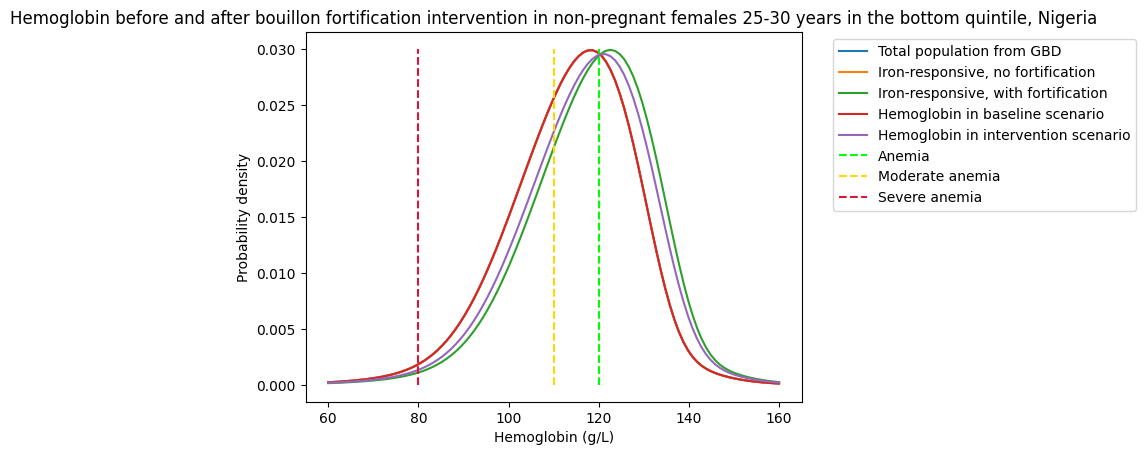

In [91]:
import matplotlib.pyplot as plt

x_values = np.linspace(60, 160, 100)
with np.errstate(under="ignore"):
    plt.plot(
        x_values,
        [total_population_pdf(x) for x in x_values],
        label="Total population from GBD",
    )
    plt.plot(
        x_values,
        [iron_responsive_zero_fort_pdf(x) for x in x_values],
        label="Iron-responsive, no fortification",
    )
    plt.plot(
        x_values,
        [iron_responsive_with_fort_pdf(x) for x in x_values],
        label="Iron-responsive, with fortification",
    )
    plt.plot(
        x_values,
        [baseline_pdf(x) for x in x_values],
        label="Hemoglobin in baseline scenario",
    )
    plt.plot(
        x_values,
        [intervention_pdf(x) for x in x_values],
        label="Hemoglobin in intervention scenario",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_mild,
        0,
        0.03,
        linestyles="dashed",
        label="Anemia",
        color="lime",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_moderate,
        0,
        0.03,
        linestyles="dashed",
        label="Moderate anemia",
        color="gold",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_severe,
        0,
        0.03,
        linestyles="dashed",
        label="Severe anemia",
        color="crimson",
    )
    plt.xlabel("Hemoglobin (g/L)")
    plt.ylabel("Probability density")
    plt.title(
        f"Hemoglobin before and after {vehicle} fortification intervention in non-pregnant females 25-30 years in the bottom quintile, {location.title()}"
    )
    plt.legend(bbox_to_anchor=(1.05, 1))

In [92]:
(baseline_anemia - intervention_anemia).sort_values("anemic")

severe  \
sex    age_start age_end   wealth_quintile draw     scenario                     
Male   0.0       0.019178  1               draw_363 intervention  4.783873e-05   
                                           draw_353 intervention  1.084941e-04   
                                           draw_161 intervention  2.667053e-04   
                                           draw_81  intervention  1.011112e-04   
                                           draw_174 intervention  8.484332e-04   
...                                                                        ...   
                           5               draw_29  intervention  1.138098e-08   
                                           draw_408 intervention  2.814525e-08   
                                           draw_27  intervention  3.416443e-08   
Female 85.0      90.000000 5               draw_2   intervention  1.227567e-05   
Male   0.0       0.019178  5               draw_481 intervention  4.718783e-08   

                                                                  moderate  \
sex    age_start age_end   wealth_quintile draw     scenario                 
Male   0.0       0.019178  1               draw_363 intervention  0.073681   
                                           draw_353 intervention  0.053448   
                                           draw_161 intervention  0.047489   
                                           draw_81  intervention  0.082233   
                                           draw_174 intervention  0.023762   
...                                                                    ...   
                           5               draw_29  intervention  0.003768   
                                           draw_408 intervention  0.005516   
                                           draw_27  intervention  0.006591   
Female 85.0      90.000000 5               draw_2   intervention  0.048208   
Male   0.0       0.019178  5               draw_481 intervention  0.010995   

                                                                      mild  \
sex    age_start age_end   wealth_quintile draw     scenario                 
Male   0.0       0.019178  1               draw_363 intervention -0.073691   
                                           draw_353 intervention -0.053505   
                                           draw_161 intervention -0.047645   
                                           draw_81  intervention -0.082214   
                                           draw_174 intervention -0.024474   
...                                                                    ...   
                           5               draw_29  intervention  0.242033   
                                           draw_408 intervention  0.243414   
                                           draw_27  intervention  0.246433   
Female 85.0      90.000000 5               draw_2   intervention  0.211745   
Male   0.0       0.019178  5               draw_481 intervention  0.251224   

                                                                    anemic  
sex    age_start age_end   wealth_quintile draw     scenario                
Male   0.0       0.019178  1               draw_363 intervention  0.000038  
                                           draw_353 intervention  0.000051  
                                           draw_161 intervention  0.000111  
                                           draw_81  intervention  0.000120  
                                           draw_174 intervention  0.000136  
...                                                                    ...  
                           5               draw_29  intervention  0.245802  
                                           draw_408 intervention  0.248930  
                                           draw_27  intervention  0.253023  
Female 85.0      90.000000 5               draw_2   intervention  0.259965  
Male   0.0       0.019178  5               draw_481

In [93]:
def anemia_to_yld_rates(anemia):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia.index
    anemia = (
        anemia.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia["mild_yld_rate"] = anemia.mild * anemia.mild_dw
    anemia["moderate_yld_rate"] = anemia.moderate * anemia.moderate_dw
    anemia["severe_yld_rate"] = anemia.severe * anemia.severe_dw
    anemia["anemic_yld_rate"] = (
        anemia["mild_yld_rate"]
        + anemia["moderate_yld_rate"]
        + anemia["severe_yld_rate"]
    )

    return anemia.set_index(orig_index.names).filter(like="yld_rate")

In [94]:
zero_fort_anemia_yld_rates = anemia_to_yld_rates(zero_fort_anemia)
zero_fort_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    draw    wealth_quintile                  
Female 0.0       0.019178   draw_0  1                     0.000484   
                                    2                     0.000528   
                                    3                     0.000570   
                                    4                     0.000612   
                                    5                     0.000664   
...                                                            ...   
Male   95.0      125.000000 draw_99 1                     0.001164   
                                    2                     0.001250   
                                    3                     0.001270   
                                    4                     0.001299   
                                    5                     0.001405   

                                                     moderate_yld_rate  \
sex    age_start age_end    draw    wealth_quintile                      
Female 0.0       0.019178   draw_0  1                         0.030969   
                                    2                         0.029801   
                                    3                         0.027580   
                                    4                         0.027066   
                                    5                         0.022656   
...                                                                ...   
Male   95.0      125.000000 draw_99 1                         0.020209   
                                    2                         0.019831   
                                    3                         0.019421   
                                    4                         0.019551   
                                    5                         0.019197   

                                                     severe_yld_rate  \
sex    age_start age_end    draw    wealth_quintile                    
Female 0.0       0.019178   draw_0  1                       0.022453   
                                    2                       0.016943   
                                    3                       0.012010   
                                    4                       0.009117   
                                    5                       0.004930   
...                                                              ...   
Male   95.0      125.000000 draw_99 1                       0.020684   
                                    2                       0.018173   
                                    3                       0.017800   
                                    4                       0.016788   
                                    5                       0.013773   

                                                     anemic_yld_rate  
sex    age_start age_end    draw    wealth_quintile                   
Female 0.0       0.019178   draw_0  1                       0.053906  
                                    2                       0.047272  
                                    3                       0.040160  
                                    4                       0.036795  
                                    5                       0.028250  
...                                                              ...  
Male   95.0      125.000000 draw_99 1                       0.042057  
                                    2                       0.039253  
                                    3                       0.038492  
                                    4                       0.037638  
                                    5                       0.034375  

[125000 rows x 4 columns]

In [95]:
baseline_anemia_yld_rates = anemia_to_yld_rates(baseline_anemia)
baseline_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                     
Female 0.0       0.019178   1               draw_0        0.000484   
                            2               draw_0        0.000528   
                            3               draw_0        0.000570   
                            4               draw_0        0.000612   
                            5               draw_0        0.000664   
...                                                            ...   
Male   95.0      125.000000 1               draw_99       0.001164   
                            2               draw_99       0.001250   
                            3               draw_99       0.001270   
                            4               draw_99       0.001299   
                            5               draw_99       0.001405   

                                                     moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0            0.030969   
                            2               draw_0            0.029801   
                            3               draw_0            0.027580   
                            4               draw_0            0.027066   
                            5               draw_0            0.022656   
...                                                                ...   
Male   95.0      125.000000 1               draw_99           0.020209   
                            2               draw_99           0.019831   
                            3               draw_99           0.019421   
                            4               draw_99           0.019551   
                            5               draw_99           0.019197   

                                                     severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0          0.022453   
                            2               draw_0          0.016943   
                            3               draw_0          0.012010   
                            4               draw_0          0.009117   
                            5               draw_0          0.004930   
...                                                              ...   
Male   95.0      125.000000 1               draw_99         0.020684   
                            2               draw_99         0.018173   
                            3               draw_99         0.017800   
                            4               draw_99         0.016788   
                            5               draw_99         0.013773   

                                                     anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0          0.053906  
                            2               draw_0          0.047272  
                            3               draw_0          0.040160  
                            4               draw_0          0.036795  
                            5               draw_0          0.028250  
...                                                              ...  
Male   95.0      125.000000 1               draw_99         0.042057  
                            2               draw_99         0.039253  
                            3               draw_99         0.038492  
                            4               draw_99         0.037638  
                            5               draw_99         0.034375  

[125000 rows x 4 columns]

In [96]:
(
    baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()
    - anemia_to_yld_rates(iron_responsive_with_fort_anemia)
    .loc[("Female", 25, 30, 1)]
    .mean()
) / baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate        0.095851
moderate_yld_rate    0.283511
severe_yld_rate      0.356373
anemic_yld_rate      0.282946
dtype: float64

In [97]:
intervention_anemia_yld_rates = anemia_to_yld_rates(intervention_anemia)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                      
Female 0.0       0.019178   1               draw_0  intervention       0.000505   
                            2               draw_0  intervention       0.000543   
                            3               draw_0  intervention       0.000575   
                            4               draw_0  intervention       0.000614   
                            5               draw_0  intervention       0.000647   
...                                                                         ...   
Male   95.0      125.000000 1               draw_99 intervention       0.001287   
                            2               draw_99 intervention       0.001364   
                            3               draw_99 intervention       0.001375   
                            4               draw_99 intervention       0.001407   
                            5               draw_99 intervention       0.001505   

                                                                  moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                          
Female 0.0       0.019178   1               draw_0  intervention           0.029297   
                            2               draw_0  intervention           0.027797   
                            3               draw_0  intervention           0.025312   
                            4               draw_0  intervention           0.024506   
                            5               draw_0  intervention           0.019930   
...                                                                             ...   
Male   95.0      125.000000 1               draw_99 intervention           0.019109   
                            2               draw_99 intervention           0.018570   
                            3               draw_99 intervention           0.018158   
                            4               draw_99 intervention           0.018197   
                            5               draw_99 intervention           0.017639   

                                                                  severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                        
Female 0.0       0.019178   1               draw_0  intervention         0.019132   
                            2               draw_0  intervention         0.014228   
                            3               draw_0  intervention         0.009985   
                            4               draw_0  intervention         0.007487   
                            5               draw_0  intervention         0.004039   
...                                                                           ...   
Male   95.0      125.000000 1               draw_99 intervention         0.017319   
                            2               draw_99 intervention         0.015053   
                            3               draw_99 intervention         0.014756   
                            4               draw_99 intervention         0.013810   
                            5               draw_99 intervention         0.011185   

                                                                  anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw    scenario                       
Female 0.0       0.019178   1               draw_0  intervention         0.048934  
                            2               draw_0  intervention         0.042568  
                            3               draw_0  intervention         0.035873  
                            4               draw_0  intervention         0.032607  
                            5               draw_0  intervention         0.024616  
...                                                                           ...  
Male   95.0      125.000000 1               draw_99 intervention         0.0

In [98]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex  age_start age_end   wealth_quintile draw     scenario                      
Male 25.0      30.000000 5               draw_38  intervention       0.000012   
                                         draw_34  intervention       0.000025   
                                         draw_420 intervention       0.000035   
                                         draw_106 intervention       0.000023   
                                         draw_472 intervention       0.000048   
...                                                                       ...   
     10.0      15.000000 1               draw_51  intervention       0.000138   
     0.0       0.019178  2               draw_150 intervention      -0.000531   
                         1               draw_53  intervention      -0.001627   
                                         draw_408 intervention      -0.000778   
                         2               draw_408 intervention      -0.000768   

                                                                moderate_yld_rate  \
sex  age_start age_end   wealth_quintile draw     scenario                          
Male 25.0      30.000000 5               draw_38  intervention           0.000034   
                                         draw_34  intervention           0.000037   
                                         draw_420 intervention           0.000031   
                                         draw_106 intervention           0.000043   
                                         draw_472 intervention           0.000022   
...                                                                           ...   
     10.0      15.000000 1               draw_51  intervention           0.012050   
     0.0       0.019178  2               draw_150 intervention           0.012838   
                         1               draw_53  intervention           0.014262   
                                         draw_408 intervention           0.013910   
                         2               draw_408 intervention           0.014146   

                                                                severe_yld_rate  \
sex  age_start age_end   wealth_quintile draw     scenario                        
Male 25.0      30.000000 5               draw_38  intervention     4.770530e-06   
                                         draw_34  intervention     4.224952e-06   
                                         draw_420 intervention     1.821782e-06   
                                         draw_106 intervention     4.986973e-06   
                                         draw_472 intervention     5.837959e-07   
...                                                                         ...   
     10.0      15.000000 1               draw_51  intervention     3.514777e-05   
     0.0       0.019178  2               draw_150 intervention     1.999737e-05   
                         1               draw_53  intervention     1.074619e-05   
                                         draw_408 intervention     9.600000e-06   
                         2               draw_408 intervention     2.858169e-06   

                                                                anemic_yld_rate  
sex  age_start age_end   wealth_quintile draw     scenario                       
Male 25.0      30.000000 5               draw_38  intervention         0.000050  
                                         draw_34  intervention         0.000066  
                                         draw_420 intervention         0.000068  
                                         draw_106 intervention         0.000070  
                                         draw_472 intervention         0.000071  
...                                                                         ...  
     10.0      15.000000 1               draw_51  intervention         0.012223  
     0.0       0.019178  2               draw_150 intervention         0.012327  
    

In [99]:
assert (
    (baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate >= 0
).all()

In [100]:
zero_fort_ylds = (
    zero_fort_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  736.111714
                               2                  650.757670
                               3                  521.550200
                               4                  424.729902
                               5                  291.089988
                                                     ...    
Male    95.0       125.000000  1                   89.386189
                               2                   72.903842
                               3                   73.428445
                               4                   76.888359
                               5                   74.821911
Length: 250, dtype: float64

In [101]:
baseline_ylds = (
    baseline_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  736.111714
                               2                  650.757670
                               3                  521.550200
                               4                  424.729902
                               5                  291.089988
                                                     ...    
Male    95.0       125.000000  1                   89.386189
                               2                   72.903842
                               3                   73.428445
                               4                   76.888359
                               5                   74.821911
Length: 250, dtype: float64

In [102]:
intervention_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    665.769665
                               2                intervention    578.960797
                               3                intervention    454.500499
                               4                intervention    364.571097
                               5                intervention    241.119091
                                                                   ...    
Male    95.0       125.000000  1                intervention     80.041483
                               2                intervention     64.926221
                               3                intervention     65.384278
                               4                intervention     68.233035
                               5                intervention     66.032376
Length: 250, dtype: float64

In [103]:
(
    baseline_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_ylds.loc[("Female", 25, 30, 1)].mean()
)

5121.604720488267

In [104]:
(
    baseline_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_ylds.groupby(["wealth_quintile"]).sum()
)

wealth_quintile
1    160825.581870
2    146235.663333
3    132508.289562
4    128047.303639
5    100554.825445
dtype: float64

In [105]:
ylds = pd.concat(
    [
        zero_fort_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_ylds.rename("value").reset_index().assign(scenario="baseline"),
        intervention_ylds.rename("value").reset_index().assign(scenario="intervention"),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,736.111714,zero
1,Female,0.0,0.019178,2,650.757670,zero
2,Female,0.0,0.019178,3,521.550200,zero
3,Female,0.0,0.019178,4,424.729902,zero
4,Female,0.0,0.019178,5,291.089988,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,80.041483,intervention
746,Male,95.0,125.000000,2,64.926221,intervention
747,Male,95.0,125.000000,3,65.384278,intervention
748,Male,95.0,125.000000,4,68.233035,intervention


In [106]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [107]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [108]:
zero_fort_anemia_prevalence = zero_fort_anemia["anemic"].unstack("draw").mean(axis=1)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.900708
                               2                  0.876689
                               3                  0.835819
                               4                  0.828338
                               5                  0.748522
                                                    ...   
Male    95.0       125.000000  1                  0.910303
                               2                  0.899321
                               3                  0.890964
                               4                  0.891835
                               5                  0.880907
Length: 250, dtype: float64

In [109]:
baseline_anemia_prevalence = baseline_anemia["anemic"].unstack("draw").mean(axis=1)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.900708
                               2                  0.876689
                               3                  0.835819
                               4                  0.828338
                               5                  0.748522
                                                    ...   
Male    95.0       125.000000  1                  0.910303
                               2                  0.899321
                               3                  0.890964
                               4                  0.891835
                               5                  0.880907
Length: 250, dtype: float64

In [110]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  15276.458404
                               2                  14808.048479
                               3                  13328.773023
                               4                  11611.609394
                               5                   9753.105130
                                                      ...     
Male    95.0       125.000000  1                   1681.299915
                               2                   1453.600055
                               3                   1480.290163
                               4                   1586.629929
                               5                   1671.057535
Length: 250, dtype: float64

In [111]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.4586740701563642

In [112]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  15276.458404
                               2                  14808.048479
                               3                  13328.773023
                               4                  11611.609394
                               5                   9753.105130
                                                      ...     
Male    95.0       125.000000  1                   1681.299915
                               2                   1453.600055
                               3                   1480.290163
                               4                   1586.629929
                               5                   1671.057535
Length: 250, dtype: float64

In [113]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.4586740701563642

In [114]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.556781
2    0.498840
3    0.454171
4    0.434832
5    0.350655
dtype: float64

In [115]:
intervention_anemia_prevalence = (
    intervention_anemia["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.871103
                               2                intervention    0.839403
                               3                intervention    0.788057
                               4                intervention    0.775447
                               5                intervention    0.678051
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.883110
                               2                intervention    0.867477
                               3                intervention    0.857072
                               4                intervention    0.856831
                               5                intervention    0.840544
Length: 250, dtype: float64

In [116]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="intervention"),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.900708,zero
1,Female,0.0,0.019178,2,0.876689,zero
2,Female,0.0,0.019178,3,0.835819,zero
3,Female,0.0,0.019178,4,0.828338,zero
4,Female,0.0,0.019178,5,0.748522,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.883110,intervention
746,Male,95.0,125.000000,2,0.867477,intervention
747,Male,95.0,125.000000,3,0.857072,intervention
748,Male,95.0,125.000000,4,0.856831,intervention


In [117]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [118]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    14774.333741
                               2                intervention    14178.260726
                               3                intervention    12567.109505
                               4                intervention    10870.182613
                               5                intervention     8834.869693
                                                                    ...     
Male    95.0       125.000000  1                intervention     1631.076668
                               2                intervention     1402.129140
                               3                intervention     1423.979719
                               4                intervention     1524.355932
                               5                intervention     1594.490008
Length: 250, dtype: float64

In [119]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.3865307935077673

In [120]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.482874
2    0.424951
3    0.381905
4    0.361589
5    0.283208
dtype: float64

In [121]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    3,272,527
2    3,289,347
3    3,231,870
4    3,306,971
5    3,031,068
dtype: object

In [122]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value")
        .reset_index()
        .assign(scenario="intervention"),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,15276.458404,zero
1,Female,0.0,0.019178,2,14808.048479,zero
2,Female,0.0,0.019178,3,13328.773023,zero
3,Female,0.0,0.019178,4,11611.609394,zero
4,Female,0.0,0.019178,5,9753.105130,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,1631.076668,intervention
746,Male,95.0,125.000000,2,1402.129140,intervention
747,Male,95.0,125.000000,3,1423.979719,intervention
748,Male,95.0,125.000000,4,1524.355932,intervention


In [123]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)